# Imports

In [1]:
from IPython.display import Image, display, SVG, HTML
from typing import Dict, List, Tuple, Generator, Optional

from interval_timeline import CallGraph
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import re

from tqdm import tqdm
import otf2
import hatchet as ht
import thicket as tt
from collections import defaultdict

# Preamble

### Define The Name of the Cluster & Trace Paths

Define the name of the cluster and the paths to the trace files.
This is needed to parse the trace directory paths correctly as generated by the master run script.

In [2]:
CLUSTER_NAME = "frontier"

ROOT_TRACE_DIR = "./benchmark-results"

### Define Which Ranks Run on Each Node

Define the topology of the runs. This is needed to attribute energy consumption correctly. Metrics are gathered at the node level, so we
need to know which node each rank ran on to get the metrics associated with that node + rank.

In [3]:
HPL_NODE_RANKS = {
	'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7'],
}
HPG_NODE_RANKS = HPL_NODE_RANKS

### Define The Metrics to Attribute to Each Rank

This defines which MPI rank is on which GCD (frontier) or APU (el capitan). Two ranks drawing from the same GPU (each GPU has 2 GCDs) will have their energy consumption estimated independently based on their exclusive runtime.

In [4]:
HPL_RANKS_TO_METRICS = {
	'MPI Rank 0': ['A2rocm_smi:::energy_count:device=4'],
	'MPI Rank 1': ['A2rocm_smi:::energy_count:device=4'],
	'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 3': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 4': ['A2rocm_smi:::energy_count:device=6'],
	'MPI Rank 5': ['A2rocm_smi:::energy_count:device=6'],
	'MPI Rank 6': ['A2rocm_smi:::energy_count:device=0'],
	'MPI Rank 7': ['A2rocm_smi:::energy_count:device=0'],
}

HPG_RANKS_TO_METRICS = HPL_RANKS_TO_METRICS

### Define Which Metrics to Track in the Traces

This defines the metrics we're going to pay attention to when parsing the traces.
All metrics that are used above must be included here.

In [5]:

METRICS_TO_ATTRIBUTE = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',
    
    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
]

In [6]:
# Glob everything from `./scorep-traces/frontierXXXXX-rochpl-*`
ROCHPL_BASE = "rochpl--P_1_-Q_8_-N_245760"
ROCHPL_MXP_BASE = "rochplmxp--P_1_-Q_8_-N_245760"
HPG_BASE = "xhpgmp-128_128_128_--run_type=standalone_ref"
HPG_MXP_BASE = "xhpgmp-128_128_128_--run_type=standalone_mxp"

ROCHPL_TRACES = [
    f"{ROOT_TRACE_DIR}/{ROCHPL_BASE}/{d}/traces.otf2"
	for d in os.listdir(f"{ROOT_TRACE_DIR}/{ROCHPL_BASE}/")
	if re.match(rf"trial_\d+-{CLUSTER_NAME}\d+-rochpl-.*", d) and os.path.isdir(f"{ROOT_TRACE_DIR}/{ROCHPL_BASE}/{d}")
]

ROCHPL_MXP_TRACES = [
    f"{ROOT_TRACE_DIR}/{ROCHPL_MXP_BASE}/{d}/traces.otf2"
	for d in os.listdir(f"{ROOT_TRACE_DIR}/{ROCHPL_MXP_BASE}/")
	if re.match(rf"trial_\d+-{CLUSTER_NAME}\d+-rochplmxp-.*", d) and os.path.isdir(f"{ROOT_TRACE_DIR}/{ROCHPL_MXP_BASE}/{d}")
]

HPG_TRACES = [
    f"{ROOT_TRACE_DIR}/{HPG_BASE}/{d}/traces.otf2"
	for d in os.listdir(f"{ROOT_TRACE_DIR}/{HPG_BASE}/")
	if re.match(rf"trial_\d+-{CLUSTER_NAME}\d+-xhpgmp-.*--run_type=standalone_ref", d) and os.path.isdir(f"{ROOT_TRACE_DIR}/{HPG_BASE}/{d}")
]

HPG_MXP_TRACES = [
    f"{ROOT_TRACE_DIR}/{HPG_MXP_BASE}/{d}/traces.otf2"
	for d in os.listdir(f"{ROOT_TRACE_DIR}/{HPG_MXP_BASE}/")
	if re.match(rf"trial_\d+-{CLUSTER_NAME}\d+-xhpgmp-.*--run_type=standalone_mxp", d) and os.path.isdir(f"{ROOT_TRACE_DIR}/{HPG_MXP_BASE}/{d}")
]

print("ROCHPL_TRACES:", ROCHPL_TRACES)
print("ROCHPL_MXP_TRACES:", ROCHPL_MXP_TRACES)
print("HPG_TRACES:", HPG_TRACES)
print("HPG_MXP_TRACES:", HPG_MXP_TRACES)


    

ROCHPL_TRACES: ['./benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_3-frontier04527-rochpl--P_1_-Q_8_-N_245760/traces.otf2', './benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_1-frontier04529-rochpl--P_1_-Q_8_-N_245760/traces.otf2', './benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_2-frontier04528-rochpl--P_1_-Q_8_-N_245760/traces.otf2', './benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_3-frontier04530-rochpl--P_1_-Q_8_-N_245760/traces.otf2', './benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_1-frontier04528-rochpl--P_1_-Q_8_-N_245760/traces.otf2', './benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_2-frontier04529-rochpl--P_1_-Q_8_-N_245760/traces.otf2', './benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_3-frontier04528-rochpl--P_1_-Q_8_-N_245760/traces.otf2', './benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_2-frontier04527-rochpl--P_1_-Q_8_-N_245760/traces.otf2', './benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_1-frontier04530-rochpl--P_1_-Q_8_-N_245760

### Metrics
Which metrics to trace, and functions for reading/writing them to CSVs.

In [7]:
def callgraph_to_csv(call_graph: CallGraph, group: str, thread: str, filename: str):
    """Convert a CallGraph to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Thread,Group,Depth,Name,Start Time,End Time,Duration\n")
        intervals = call_graph.get_intervals_between(float('-inf'), float('inf'))
        
        for interval in intervals:
            start = interval.start
            end = interval.end or float('inf')
            duration = end - start
            name = interval.name if interval.name else "Unknown"
            depth = interval.depth if interval.depth else 0

            f.write(f"{thread},{group},{depth},\"{name}\",{start},{end},{duration}\n")

def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    df = pd.read_csv(file)
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name:
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    return pd.read_csv(file)


### Remove Conflicting CSVs
Remove any existing CSVs that might conflict with new ones to be generated.

In [8]:
# Remove all the old CSV files
for file in os.listdir('.'):
    if file.endswith('.csv'):
        os.remove(file)

### Setup for Loading Traces
Convert an OTF2 to a CSV dataset to be loaded into a dataframe

In [9]:
def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str] = METRICS_TO_ATTRIBUTE, cray_time_offset=0.0):
	call_graphs = {}
	metrics = {}

	start_time = None
	timer_resolution = None

	seen: Dict[str, set[str]] = {}

	def timestamp_to_seconds(timestamp):
		"""Convert a timestamp in nanoseconds to seconds."""
		if timestamp is None or start_time is None or timer_resolution is None:
			return 0.0
		return (timestamp - start_time) / timer_resolution

	with otf2.reader.open(trace) as reader:
		defs = reader.definitions
		timer_resolution = reader.timer_resolution
		print(f"Timer resolution: {timer_resolution} ticks per second ({timer_resolution / 1e9} per nanosecond)")
		print(f"Number of metric members: {len(defs.metric_members)}")
		print(f'Definitions: {defs}')
		count = 0
		for location, event in reader.events:
			count += 1
			# thread = (location.name, location.group.name)
			group = location.group.name
			if location.group.creating_location_group is not None:
				group = location.group.creating_location_group.name
			thread = location.name
			
			if group not in seen:
				seen[group] = set()
			if thread not in seen[group]:
				seen[group].add(thread)
				print(f"New thread: {thread} in group {group}")
			if group not in call_graphs:
				call_graphs[group] = {thread: CallGraph()}
			if thread not in call_graphs[group]:
				call_graphs[group][thread] = CallGraph()
			if group not in metrics:
				metrics[group] = {metric: [] for metric in metrics_to_track}
			
			if isinstance(event, otf2.events.ProgramBegin):
				start_time = event.time
				continue
			elif isinstance(event, otf2.events.ProgramEnd):
				end_time = event.time
				continue
			
			current_time = timestamp_to_seconds(event.time)
			
			if isinstance(event, otf2.events.Metric):
				metric_name = event.member.name
				if group not in metrics:
					continue
				if metric_name not in metrics[group]:
					continue
				if 'cray' in metric_name and cray_time_offset != 0.0:
					current_time -= cray_time_offset  # Adjust for craypm metrics, as they are reported with a delay
				
				if len(metrics[group][metric_name]) == 0 or metrics[group][metric_name][-1][1] != event.value:
					# If the metrics has no initial value, append the current one
					# If the metric has changed, append the current one
					metrics[group][metric_name].append((current_time, event.value))
				
			if group not in processes_to_track:
				continue
			
			if isinstance(event, otf2.events.Enter):
				if 'mpi' in event.region.name.lower()[:3]:
					continue
				if 'hip' in event.region.name.lower()[:3]:
					continue
				call_graphs[group][thread].enter(current_time, name=event.region.name)
			elif isinstance(event, otf2.events.Leave):
				try:
					if 'mpi' in event.region.name.lower()[:3]:
						continue
					if 'hip' in event.region.name.lower()[:3]:
						continue
					call_graphs[group][thread].leave(current_time)
				except Exception as e:
					print(f"Error leaving call graph for {group} {thread}: {e}")
					continue
		print(f"Processed {count} events.")
		
	for group, threads in call_graphs.items():
		if group not in processes_to_track:
			print(f"Skipping group {group} as it is not in the processes to track.")
			continue
		for thread, call_graph in threads.items():
			filename = f"{group}_{thread.replace(' ', '_')}_callgraph.csv"
			print(f'Writing to file: {filename}')
			callgraph_to_csv(call_graph, group, thread, filename)

	for group, thread_metrics in metrics.items():
		if group not in processes_to_track:
			print(f"Skipping group {group} as it is not in the processes to track.")
			continue
		filename = f"{group}_metrics.csv"
		print(f'Writing to file: {filename}')
		metrics_to_csv(group, thread_metrics, filename)
	
# Visualize the dataframes
def visualize_dataframe(df):
	"""Visualize the first few rows of a DataFrame as HTML."""
	# pd.set_option("display.width", 2400)
	# pd.set_option("display.max_colwidth", 100)
	# pd.set_option("display.max_rows", 20)
	
	display(HTML(df.head(n=20).to_html(index=False)))


### Math Helpers

Helpers for linearly interpolating values and computing numerical integrals + derivatives

In [10]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    # Apply a savgol filter to smooth the data
    # y = scipy.signal.savgol_filter(y, window_length=11, polyorder=2, mode='nearest')
    # Apply a median filter to smooth the data
    # y = scipy.signal.medfilt(y, kernel_size=11)
 
    # Create a continuous function that interpolates the sampled data
    f = lambda t: np.interp(t, t_samples, y)
    return f

def numerical_derivative(func, h=1e-5):
    """Compute the numerical derivative of a function at a point t."""
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    """
    Return a function F(x) that approximates the integral of f(t) dt from t=a to t=x,
    using the trapezoidal rule in a fully vectorized manner.
    The function F(x) will return a scalar when x is a scalar, and an array
    when x is an array.
    """
    # Determinar si f soporta arrays de NumPy
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Manejo de x < a invirtiendo signo
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        # Grid hasta el máximo de x
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        # Suma acumulada de trapecios
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        # Índices y remanentes
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        # Valores en fronteras
        f_end = f_np(x_pos)
        f_start = u[idx]
        
        # Integral aproximada
        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        # Devolver escalares cuando corresponda
        return result.item() if np.isscalar(x) else result
    
    return F
        
def unwrap_or_zero(f):
    if not f:
        return 0.0
    else:
        return f


### Thicket + Hatchet Integration
Convert the CSV datasets into thicket/hatchet objects for analysis

In [11]:
def create_hatchet_dag(call_graph_df: pd.DataFrame, metric_functions: Dict[str, callable]):
    df = call_graph_df.copy()
    # Asume que viene “bien formado”: cada fila es una invocación con Depth que respeta el anidamiento.
    # Si no está ordenado por Start Time, ordénalo una vez.
    df = df.sort_values(by='Start Time')

    # Filtrado opcional por duración, replica tu lógica si quieres:
    df = df[df['Duration'] >= 0.001]

    pref3 = df['Name'].str[:3].str.lower()
    df = df[~pref3.isin(['hip', 'mpi'])]
    
    # Vectoriza cálculo de métricas por fila (Δ = f(end) - f(start))
    starts = df['Start Time'].to_numpy()
    ends   = df['End Time'].to_numpy()
    names  = df['Name'].to_numpy()
    depths = df['Depth'].to_numpy()
    durs   = df['Duration'].to_numpy()


    metrics_cols = {}
    for metric, f in tqdm(metric_functions.items()):
        try:
            vals = f(ends) - f(starts)            # ideal: f soporta arrays
            vals = np.asarray(vals, dtype=float)
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        except Exception:
            # Fallback si f no vectoriza
            vals = np.fromiter(
                (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                dtype=float, count=len(starts)
            )
        metrics_cols[metric] = vals

    # Construcción del DAG con una pila indexada por profundidad
    # Mantenemos las referencias a los últimos nodos por cada Depth.
    # Cuando Depth sube, el nuevo nodo se anexa como hijo del nodo en Depth-1.
    dag_roots: list = []
    last_at_depth: dict[int, dict] = {}

    # Usamos itertuples para bajo overhead
    M = len(df)
    for i, (name, depth, dur) in enumerate(zip(names, depths, durs)):
        node_metrics = {'time (inc)': float(dur), 'time': 0.0}
        for m, arr in metrics_cols.items():
            node_metrics[m] = float(arr[i])

        node = {'frame': {'name': name}, 'metrics': node_metrics, 'children': []}

        if depth == 0 or (depth - 1) not in last_at_depth:
            dag_roots.append(node)
        else:
            parent = last_at_depth[depth - 1]
            parent['children'].append(node)

        last_at_depth[depth] = node

        # Si retrocede la profundidad en la siguiente fila, iremos sobreescribiendo last_at_depth
        # No hace falta “cerrar” nada aún; calculamos 'time' más adelante en una segunda pasada.

    # Segunda pasada postorden para calcular 'time' = 'time (inc)' - suma hijos.
    # Podemos hacerlo con una DFS iterativa.
    stack = [(root, False) for root in dag_roots]
    while stack:
        node, visited = stack.pop()
        if not visited:
            stack.append((node, True))
            for ch in node['children']:
                stack.append((ch, False))
        else:
            child_incs = 0.0
            for ch in node['children']:
                child_incs += ch['metrics']['time (inc)']
            node['metrics']['time'] = node['metrics']['time (inc)'] - child_incs

    return dag_roots

# Hierarchical DataFrames

Organize the data into hierarchical dataframes for easier analysis:
- `Ensemble`: all the runs of a given configuration
- `Run`: a single run of a configuration
- `Node`: a single node in a run
- `Rank`: a single MPI rank in a node

In [12]:
class Rank:
	def __init__(self, node: str, name: str, call_graph_df: pd.DataFrame):
		self.node = node
		self.name = name
		self.call_graph = call_graph_df
		assert self.call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph_df.columns.tolist()}"
		
	def get_all_code_regions(self) -> List[str]:
		return self.call_graph['Name'].unique().tolist()

	def compute_attribution(
		self,
		metrics_accumulated: Dict[str, callable],
		duration_threshold: float = 0.001,
		weights_by_metric: Optional[Dict[str, np.ndarray]] = None):
		df = self.call_graph
		df = df[df['Duration'] >= duration_threshold]
		pref3 = df['Name'].str[:3].str.lower()
		df = df[~pref3.isin(['hip', 'mpi'])]

		if df.empty:
			return pd.DataFrame(columns=['Code Region'] + list(metrics_accumulated.keys()))

		starts = df['Start Time'].to_numpy()
		ends   = df['End Time'].to_numpy()
		names  = df['Name'].to_numpy()

		cols = {}
		for metric, f in metrics_accumulated.items():
			try:
				deltas = f(ends) - f(starts)
				deltas = np.asarray(deltas, dtype=float)
				deltas = np.nan_to_num(deltas, nan=0.0, posinf=0.0, neginf=0.0)
			except Exception:
				deltas = np.fromiter(
					(unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
					dtype=float, count=len(starts)
				)

			# Apply weights if present for this metric (1.0 if not provided)
			if weights_by_metric and metric in weights_by_metric:
				w = np.asarray(weights_by_metric[metric], dtype=float)
				if w.shape[0] == deltas.shape[0]:
					deltas = deltas * w
				elif w.size == 1:
					deltas = deltas * float(w)
				else:
					# Safe fallback if the length does not match for some reason
					deltas = deltas * 1.0

			cols[metric] = deltas

		out = pd.DataFrame(cols)
		out['Code Region'] = names
		# Aggregate by region
		out = out.groupby('Code Region', as_index=False).sum()
		return out

	def refresh(self):
		return Rank(self.node, self.name, self.call_graph)

	def __str__(self):
		return f"Rank({self.name})"

def build_inclusive_masks_for_rank(breaks, s, e, names, depths):
    """
    For each segment [breaks[i], breaks[i+1]), return a dict:
      masks[region_name][i] = True  iff the region is on the call stack
                                   (ancestor of top-of-stack) for the ENTIRE segment.
    Assumptions:
      - breaks includes all start/end times (so inside a segment no boundary occurs).
      - 'depths' is 0-based, increasing with nesting.
    """
    seg_count = breaks.size - 1
    masks = defaultdict(lambda: np.zeros(seg_count, dtype=bool))

    lefts, rights = breaks[:-1], breaks[1:]
    for i in range(seg_count):
        L, R = lefts[i], rights[i]

        # Regions that cover the whole segment (active across the entire segment)
        idx = np.where((s <= L) & (e >= R))[0]
        if idx.size == 0:
            continue

        # Top of stack depth
        dmax = depths[idx].max()

        # Inclusive chain = exactly one region per depth 0..dmax that covers the whole segment
        # (there should typically be at most one per depth due to proper nesting)
        for d in range(dmax + 1):
            cand = idx[depths[idx] == d]
            if cand.size:
                # If instrumentation duplicates exist at same depth, pick the one that covers the segment;
                # here cand already covers segment; pick the first deterministically.
                j = cand[0]
                masks[names[j]][i] = True

    return masks

class Node:
	def __init__(self, name: str, metrics_df: pd.DataFrame, ranks: List[Rank]):
		self.name = name
		self.ranks = ranks
		self.metrics = metrics_df
		assert self.metrics.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"

	def refresh(self):
		return Node(self.name, self.metrics, [rank.refresh() for rank in self.ranks])

	def get_metric_names(self) -> List[str]:
		return self.metrics['Metric Name'].unique().tolist()
	
	def get_metric_samples(self, metric_name: str) -> pd.DataFrame:
		return self.metrics[self.metrics['Metric Name'] == metric_name]

	def _filtered_callgraph(self, rank: Rank, duration_threshold: float):
		df = rank.call_graph
		df = df[df['Duration'] >= duration_threshold]
		pref3 = df['Name'].str[:3].str.lower()
		df = df[~pref3.isin(['hip', 'mpi'])]
		# Finite and non-degenerate
		mfin = np.isfinite(df['Start Time']) & np.isfinite(df['End Time'])
		df = df[mfin & (df['End Time'] > df['Start Time'])]
		return df

	def compute_attribution(
		self,
		ranks_to_metrics: Dict[str, List[str]] = {},
		instantaneous_metrics = [],
		duration_threshold: float = 0.001,
	):
		# --- Only the metrics actually used ---
		used_metrics = sorted({m for ml in ranks_to_metrics.values() for m in ml})
		if not used_metrics:
			return pd.DataFrame(columns=['Code Region'])

		# accumulated f(t) per metric (if instantaneous, integrate first)
		metrics_continuous = {m: sampled_to_continuous(self.get_metric_samples(m)) for m in used_metrics}
		metrics_accumulated = {
			m: (numerical_integral(metrics_continuous[m]) if m in instantaneous_metrics else metrics_continuous[m])
			for m in used_metrics
		}
		print(f"Node {self.name} has metrics: {list(metrics_accumulated.keys())}")

		# --- Pre-filtered by rank (and base arrays, incl. Depth) ---
		rank_df = {r.name: self._filtered_callgraph(r, duration_threshold) for r in self.ranks}
		rank_events = {
			rname: (
				df['Start Time'].to_numpy(),
				df['End Time'].to_numpy(),
				df['Name'].to_numpy(),
				df['Depth'].astype(int).to_numpy()
			)
			for rname, df in rank_df.items()
		}

		# metric -> ranks that use it
		metric_to_ranks: Dict[str, List[str]] = {}
		for rname, mlist in ranks_to_metrics.items():
			for m in mlist:
				metric_to_ranks.setdefault(m, []).append(rname)

		# Accumulator: per rank → per region → per metric → energy
		rank_tables: Dict[str, Dict[str, Dict[str, float]]] = {r.name: {} for r in self.ranks}

		# --- Loop per metric: segment time, split across ranks, and attribute inclusively ---
		for metric in used_metrics:
			f = metrics_accumulated[metric]
			rnames = [rn for rn in metric_to_ranks.get(metric, []) if rn in rank_events]
			if not rnames:
				continue

			# Global cuts (union of starts/ends of these ranks)
			all_s, all_e = [], []
			for rn in rnames:
				s, e, _, _ = rank_events[rn]
				if s.size:
					all_s.append(s); all_e.append(e)
			if not all_s:
				continue

			S_concat = np.concatenate(all_s)
			E_concat = np.concatenate(all_e)
			breaks = np.unique(np.concatenate([S_concat, E_concat]))
			breaks = breaks[np.isfinite(breaks)]
			if breaks.size < 2:
				continue
			seg_count = breaks.size - 1

			# ΔE per segment (sanitized)
			try:
				E_vals = f(breaks)
				E_vals = np.asarray(E_vals, dtype=float)
				if E_vals.shape != breaks.shape:
					raise ValueError
			except Exception:
				E_vals = np.array([float(f(float(t))) for t in breaks], dtype=float)

			dE = E_vals[1:] - E_vals[:-1]
			dE = np.nan_to_num(dE, nan=0.0, posinf=0.0, neginf=0.0)
			dE = np.maximum(dE, 0.0)

			# Which ranks are active in each segment?
			active_by_rank: Dict[str, np.ndarray] = {}
			lr_by_rank: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

			zeros_seg = np.zeros(seg_count, dtype=bool)
			for rn in rnames:
				s, e, _, _ = rank_events[rn]
				if s.size == 0:
					active_by_rank[rn] = zeros_seg
					lr_by_rank[rn] = (np.empty(0, dtype=int), np.empty(0, dtype=int))
					continue

				L = np.searchsorted(breaks, s, side='right') - 1
				R = np.searchsorted(breaks, e, side='left') - 1
				valid = (R >= L) & (R >= 0) & (L < seg_count)
				L = np.clip(L[valid], 0, seg_count - 1)
				R = np.clip(R[valid], 0, seg_count - 1)

				lr_by_rank[rn] = (L, R)

				# coverage count via difference array
				diff = np.zeros(seg_count + 1, dtype=int)
				# vectorized add/sub using slices
				# (loop remains but touches integers only; fast and cache-friendly)
				for l, r in zip(L, R):
					diff[l] += 1
					diff[r + 1] -= 1
				c = np.cumsum(diff[:-1])
				active_by_rank[rn] = (c > 0)

			# k(t): number of active ranks per segment
			k = np.zeros(seg_count, dtype=int)
			for rn in rnames:
				k += active_by_rank[rn].astype(int)

			# Energy share per segment for each rank: ΔE/k (if k==0, remains unattributed)
			share_per_seg = np.zeros_like(dE, dtype=float)
			mask_k = (k > 0)
			share_per_seg[mask_k] = dE[mask_k] / k[mask_k]

			# Inclusive attribution per rank: replicate share_per_seg to the entire inclusive chain
			for rn in rnames:
				s, e, names, depths = rank_events[rn]
				if s.size == 0:
					continue

				# Fast coverage masks per region using L/R (equivalent to inclusive chain under proper nesting):
				# region mask is True on segments where ANY of that region's events covers the whole segment.
				L, R = lr_by_rank[rn]
				masks: Dict[str, np.ndarray] = defaultdict(lambda: np.zeros(seg_count, dtype=bool))
				for j in range(L.size):
					l = L[j]; r = R[j]
					if r < l:
						continue
					masks[names[j]][l:r+1] = True

				# Add the SAME share_per_seg energy to each ancestor/region mask
				for region_name, seg_mask in masks.items():
					if not seg_mask.any():
						continue
					# sum over selected segments
					contrib = float(share_per_seg[seg_mask].sum())
					if contrib == 0.0:
						continue
					tbl = rank_tables[rn].setdefault(region_name, {})
					tbl[metric] = tbl.get(metric, 0.0) + contrib

		# --- Convert to per-rank DataFrames and do a wide merge ---
		attribution = None
		for rank in self.ranks:
			rn = rank.name
			# Filter only the metrics requested for this rank
			wanted = ranks_to_metrics.get(rn, [])
			if not wanted:
				continue

			rows = []
			for region, mdict in rank_tables.get(rn, {}).items():
				row = {'Code Region': region}
				# Ensure a column for each requested metric
				for m in wanted:
					row[m] = mdict.get(m, 0.0)
				rows.append(row)

			df_rank = pd.DataFrame(rows) if rows else pd.DataFrame({'Code Region': []})
			# Ensure columns if they are missing
			for m in wanted:
				if m not in df_rank.columns:
					df_rank[m] = 0.0

			# Rename metrics with rank suffix to avoid collisions
			rename_map = {m: f"{m}_{rn}" for m in wanted}
			df_rank = df_rank.rename(columns=rename_map)

			# Outer merge on 'Code Region'
			attribution = df_rank if attribution is None else pd.merge(
				attribution, df_rank, on='Code Region', how='outer'
			)

		# If there was nothing, return minimal header
		if attribution is None:
			all_cols = ['Code Region'] + [f"{m}_{r.name}" for r, ml in ranks_to_metrics.items() for m in ml]
			return pd.DataFrame(columns=all_cols)

		return attribution.fillna(0.0)

	def __str__(self):
		return f"Node(name={self.name}, ranks={[rank.name for rank in self.ranks]})"

class Run:
	def __init__(self, path: str, nodes: List[Node] = []):
		self.path = path
		self.nodes = nodes
		
	def refresh(self):
		return Run(self.path, [node.refresh() for node in self.nodes])

	@staticmethod
	def from_trace_path(trace_path: str, node_ranks: Dict[str, List[str]]):
		# Load the trace dataframes for each node and its ranks
		if not os.path.exists(trace_path):
			raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
		# print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
		# trace_to_csv(trace_path, processes, METRICS_TO_ATTRIBUTE)
		# Load the CSV files into dataframes
		all_threads = []
		for _, ranks in node_ranks.items():
			all_threads.extend(ranks)
		result = {}
		trace_to_csv(trace_path, all_threads, METRICS_TO_ATTRIBUTE)
		for node, ranks in node_ranks.items():
			metrics_df = read_metrics_dataframe(f"{ranks[0]}_metrics.csv")
			print
			assert metrics_df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"
			rank_callgraphs = []
			for rank in ranks:
				if os.path.exists(f"{rank}_Master_thread_callgraph.csv"):
					call_graph_df = read_call_graph_dataframe(f"{rank}_Master_thread_callgraph.csv")
					assert call_graph_df.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph_df.columns.tolist()}"
					# Construct the Hatchet and Thicket graphs
					rank_callgraphs.append(Rank(node, rank, call_graph_df))
			result[node] = Node(node, metrics_df, rank_callgraphs)
		return Run(trace_path, list(result.values()))

	def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
		attributions = {}
		for node in self.nodes:
			print(f"Computing attribution for node {node.name}...")
			attributions[node.name] = node.compute_attribution(ranks_to_metrics, instantaneous_metrics)
		return attributions
	
	def get_metric_samples(self, node_name: str, metric_name: str) -> pd.DataFrame:
		for node in self.nodes:
			if node.name == node_name:
				return node.get_metric_samples(metric_name)
		raise ValueError(f"Node {node_name} not found in run.")
	
	def to_thicket(self, **metadata) -> tt.Thicket:
		thickets = []
		
		for node in self.nodes:
			# self.get_metric_samples(node)
			metric_functions = {}
			for metric_name in node.get_metric_names():
				metric_functions[metric_name] = sampled_to_continuous(node.get_metric_samples(metric_name))
			
			for rank in node.ranks:
				print(f"Creating Thicket for node {node.name}, rank {rank.name}...")
				dag = create_hatchet_dag(rank.call_graph, metric_functions)
				tf = tt.Thicket.from_literal(dag)
				# tf = tt.Thicket.from_literal(dag)
				print("Thicket created from DAG.")
				tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
				tf.metadata['rank'] = rank.name
				tf.metadata['node'] = node.name
				tf.metadata = tf.metadata.assign(**metadata)
				tf.metadata.index.name = tf.dataframe.index.names[1]
		
				thickets.append(tf)
		
		print(f"Total thickets created: {len(thickets)}")
		if thickets:
			print("Combining thickets...")
			return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
		raise ValueError("No thickets were created from the run.")
		
	def __str__(self):
		return f"Run(path={self.path}, nodes={[str(node) for node in self.nodes]})"

class Ensemble:
	def __init__(self, runs: List[Run]):
		self.runs = runs
		self.attributions = {}
	
	@staticmethod
	def from_trace_paths(trace_paths: List[str], node_ranks: Dict[str, List[str]]):
		runs = []
		for path in trace_paths:
			print(f"Loading run from trace path: {path}")
			run = Run.from_trace_path(path, node_ranks)
			runs.append(run)
		return Ensemble(runs)
 
	def refresh(self):
		return Ensemble([run.refresh() for run in self.runs])
	
	def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
		if self.attributions != {}:
			print("Attributions already computed, returning cached results.")
			return self.attributions
		
		for run in self.runs:
			print(f"Computing attribution for run {run.path}...")
			self.attributions[os.path.basename(os.path.dirname(run.path))] = run.compute_attribution(ranks_to_metrics, instantaneous_metrics)
		return self.attributions
 
	def compute_attribution_across_runs(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
		attributions = self.compute_attribution(ranks_to_metrics, instantaneous_metrics)
		if not attributions:
			return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

		records = []
		for run_name, node_attribs in attributions.items():
			for node_name, df in node_attribs.items():
				if df is None or df.empty: 
					continue
				code = df['Code Region'].to_numpy()
				for metric in df.columns:
					if metric == 'Code Region': 
						continue
					vals = df[metric].to_numpy()
					# Extend in bulk (no per-iteration concatenations)
					records.extend(
						{'Run': run_name, 'Node': node_name, 'Code Region': c, 'Metric': metric, 'Value': v}
						for c, v in zip(code, vals)
					)
		return pd.DataFrame.from_records(records)

	def to_thicket(self) -> tt.Thicket:
		thickets = []
		for run in self.runs:
			name = os.path.basename(os.path.dirname(run.path))
			print(f"Creating Thicket for run {run.path} ({name})...")
			tf = run.to_thicket(trace=run.path, run=name)
			thickets.append(tf)
		if thickets:
			return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
		else:
			return tt.Thicket()

# Begin Analysis!
Load in the rocHPL data

In [ ]:
rochpl_mxp_runs = Ensemble.from_trace_paths(
    ROCHPL_MXP_TRACES,
    HPL_NODE_RANKS
)

Loading run from trace path: ./benchmark-results/rochplmxp--P_1_-Q_8_-N_245760/trial_1-frontier04528-rochplmxp--P_1_-Q_8_-N_245760/traces.otf2
Timer resolution: 1996121693 ticks per second (1.996121693 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x119d74440>
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 5
New thread:  in group MPI Rank 0


Processed 3232909 events.
Writing to file: MPI Rank 4_Master_thread_callgraph.csv
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 0_Master_thread_callgraph.csv
Writing to file: MPI Rank 0__callgraph.csv
Writing to file: MPI Rank 2_Master_thread_callgraph.csv
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 1_Master_thread_callgraph.csv
Writing to file: MPI Rank 5_Master_thread_callgraph.csv
Writing to file: MPI Rank 4_metrics.csv
Writing to file: MPI Rank 7_metrics.csv
Writing to file: MPI Rank 0_metrics.csv
Writing to file: MPI Rank 2_metrics.csv
Writing to file: MPI Rank 3_metrics.csv
Writing to file: MPI Rank 6_metrics.csv
Writing to file: MPI Rank 1_metrics.csv
Writing to file: MPI Rank 5_metrics.csv
Loading run from trace path: ./benchmark-results/rochplmxp--P_1_-Q_8_-N_245760/trial_2-frontier04530-rochplmxp--P_1_-Q_8_-N_245760/traces.otf2
Timer resolution: 19

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_2080/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.03644708e+08 2.03644708e+08 2.03644709e+08 ... 2.03652505e+08
 2.03652506e+08 2.03652506e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 0
New thread:  in group MPI Rank 0
Processed 3217268 events.
Writing to file: MPI Rank 5_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 1_Master_thread_callgraph.csv
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 4_Master_thread_callgraph.csv
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 2_Master_thread_callgraph.csv
Writing to file: MPI Rank 0_Master_thread_callgraph.csv
Writing to file: MPI Rank 0__callgraph.csv
Writing to file: MPI Rank 5_metrics.csv
Writing to file: MPI Rank 6_metrics.csv
Wr

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_2080/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.17640414e+08 2.17640415e+08 2.17640415e+08 ... 2.17647864e+08
 2.17647865e+08 2.17647865e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 5
New thread:  in group MPI Rank 0


In [ ]:
rochpl_runs = Ensemble.from_trace_paths(
    ROCHPL_TRACES,
    HPL_NODE_RANKS
)

Loading run from trace path: ./benchmark-results/rochpl--P_1_-Q_8_-N_245760/trial_3-frontier04527-rochpl--P_1_-Q_8_-N_245760/traces.otf2
Timer resolution: 1996124455 ticks per second (1.996124455 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x175a64910>
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 3
New thread:  in group MPI Rank 0


# Compare HPL full and mixed precision implementations


In [ ]:
rochpl_runs = rochpl_runs.refresh()
rochpl_mxp_runs = rochpl_mxp_runs.refresh()

rochpl_mxp_runs.attributions = {}
rochpl_mxp_run_attributions = rochpl_mxp_runs.compute_attribution_across_runs(
    ranks_to_metrics = HPL_RANKS_TO_METRICS
)

rochpl_runs.attributions = {}
rochpl_run_attributions = rochpl_runs.compute_attribution_across_runs(
    ranks_to_metrics = HPL_RANKS_TO_METRICS
)

# Sort descending by median energy
# rochpl_run_attributions = rochpl_run_attributions.sort_values(by=['Value', 'Metric'], ascending=[False, False])
# visualize_dataframe(rochpl_run_attributions)

# rocHPL vs. rocHPL-MxP Energy Heatmap
The graph below shows the average energy attribution across each HPL run and HPL-MxP run side by side.

In [ ]:
# Average all the mxp runs and non-mxp runs each
rochpl_avg = rochpl_run_attributions.copy()
rochpl_avg = rochpl_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
rochpl_avg['Run'] = 'rocHPL-full'
# Sort the dataframe by value
# rochpl_avg = rochpl_avg.sort_values(by='Value', ascending=False)

rochpl_mxp_avg = rochpl_mxp_run_attributions.copy()
rochpl_mxp_avg = rochpl_mxp_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
rochpl_mxp_avg['Run'] = 'rocHPL-mxp'


# First, replace all function names with the following function:
def replace_prefix_and_suffix(name: str) -> str:
    """Replace the prefix and everything after the `<` or `(` in the function name."""
    name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
    if '<' in name:
        name = name.split('<')[0]
    if '(' in name:
        name = name.split('(')[0]
    return name.strip()

rochpl_mxp_avg['Code Region'] = rochpl_mxp_avg['Code Region'].apply(replace_prefix_and_suffix)
rochpl_avg['Code Region'] = rochpl_avg['Code Region'].apply(replace_prefix_and_suffix)
visualize_dataframe(rochpl_avg)
visualize_dataframe(rochpl_mxp_avg)

# rochpl_mpi_funcs = rochpl_avg[rochpl_avg['Code Region'].str.contains('MPI')]
# rochpl_mxp_mpi_funcs = rochpl_mxp_avg[rochpl_mxp_avg['Code Region'].str.contains('MPI')]

heatmap_data = pd.concat([rochpl_avg, rochpl_mxp_avg])
# heatmap_data = heatmap_data[heatmap_data['Value'] > 3]
heatmap_data = heatmap_data.pivot_table(index='Code Region', columns=['Run', 'Metric'], values='Value', fill_value=0.0, sort=True)
visualize_dataframe(heatmap_data)
# Sort by the sum of both columns

# Show the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Energy Attribution Heatmap for rocHPL vs. rocHPL-mxp")
plt.xlabel("Run Type")
plt.xticks(rotation=90, ha='right')
plt.ylabel("Code Region")
plt.show()

Node,Code Region,Metric,Value,Run


Node,Code Region,Metric,Value,Run


ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1600x1200 with 0 Axes>

# See Variations Across Individual Runs of rocHPL Full Precision

Attributions already computed, returning cached results.


Run,Node,Code Region,Metric,Value
frontier02128-rochpl--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,18767.567871
frontier02128-rochpl--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,18767.567863
frontier02129-rochpl--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,18751.255106
frontier02129-rochpl--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,18751.255093
frontier02131-rochpl--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,18341.349237
frontier02131-rochpl--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,18341.349209
frontier02130-rochpl--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,18250.509231
frontier02130-rochpl--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,18250.509226
frontier02128-rochpl--P_1_-Q_8_-N_245760,node0,HPL_pdtest,A2rocm_smi:::energy_count:device=0_MPI Rank 7,18223.394657
frontier02128-rochpl--P_1_-Q_8_-N_245760,node0,HPL_pdtest,A2rocm_smi:::energy_count:device=0_MPI Rank 6,18223.234173


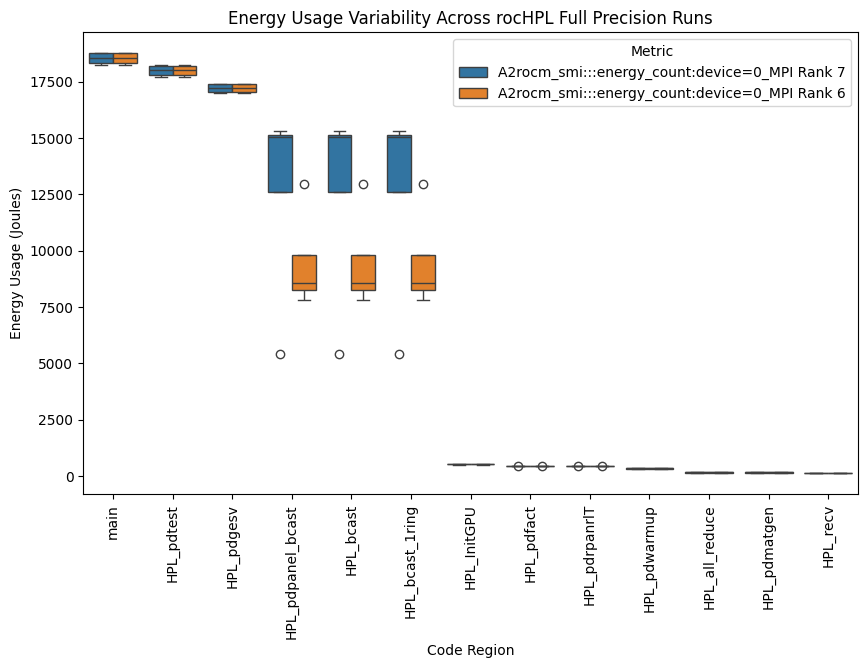

In [ ]:
run_attributions = rochpl_runs.compute_attribution_across_runs(
    ranks_to_metrics = HPL_RANKS_TO_METRICS
)

def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
    return match.group(0) if match else s

plt.figure(figsize=(10, 6))
run_attributions = run_attributions[run_attributions['Value'] > 100]  # Filter out small values
run_attributions['Code Region'] = run_attributions['Code Region'].apply(take_alphanumeric)
run_attributions = run_attributions[run_attributions['Metric'].str.contains('A2rocm_smi:::energy_count:device=0')]
run_attributions = run_attributions[run_attributions['Node'] == 'node0']
# # Only look at code regions with more than 1 entry
run_attributions = run_attributions.groupby('Code Region').filter(lambda x: len(x) > 1)
# # Sort by median value
run_attributions = run_attributions.sort_values(by='Value', ascending=False)
visualize_dataframe(run_attributions)

sns.boxplot(x='Code Region', y='Value', hue='Metric', data=run_attributions)
plt.title("Energy Usage Variability Across rocHPL Full Precision Runs")
plt.xticks(rotation=90)
plt.ylabel('Energy Usage (Joules)')
plt.show()

Attributions already computed, returning cached results.


Run,Node,Code Region,Metric,Value
frontier02128-rochplmxp--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,3960.922919
frontier02128-rochplmxp--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,3960.922903
frontier02129-rochplmxp--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,3917.590141
frontier02129-rochplmxp--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,3917.590141
frontier02130-rochplmxp--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,3772.139408
frontier02130-rochplmxp--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,3772.139369
frontier02131-rochplmxp--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,3731.193317
frontier02131-rochplmxp--P_1_-Q_8_-N_245760,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,3731.193280
frontier02128-rochplmxp--P_1_-Q_8_-N_245760,node0,HPLMXP_ptest,A2rocm_smi:::energy_count:device=0_MPI Rank 7,3308.166436
frontier02128-rochplmxp--P_1_-Q_8_-N_245760,node0,HPLMXP_ptest,A2rocm_smi:::energy_count:device=0_MPI Rank 6,3307.183298


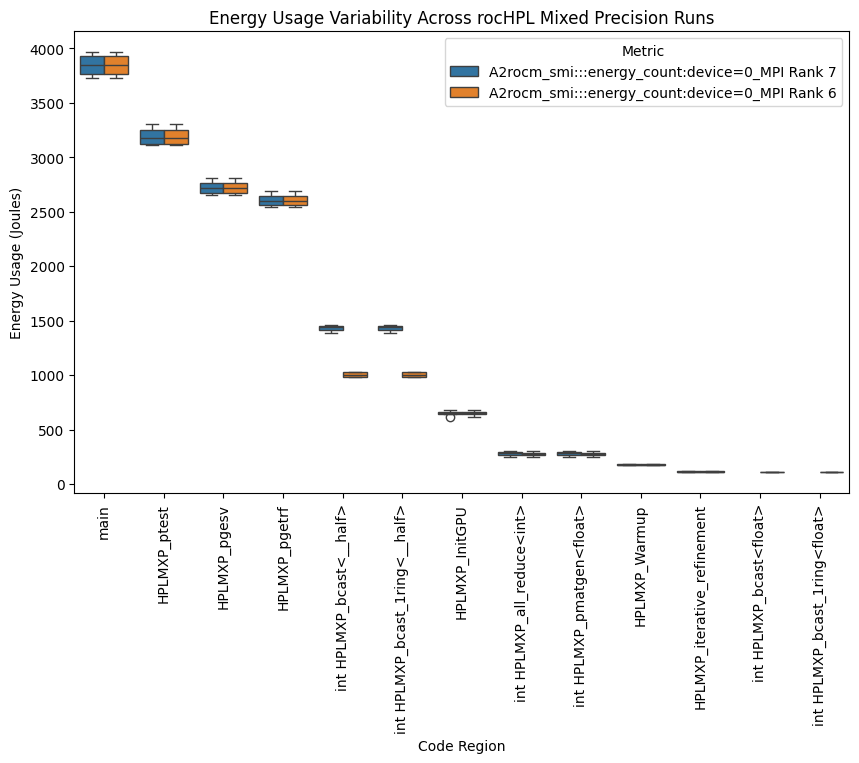

In [ ]:
run_attributions = rochpl_mxp_runs.compute_attribution_across_runs(
    ranks_to_metrics = HPL_RANKS_TO_METRICS
)

def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
    return match.group(0) if match else s

plt.figure(figsize=(10, 6))
run_attributions = run_attributions[run_attributions['Value'] > 100]  # Filter out small values
run_attributions['Code Region'] = run_attributions['Code Region'].apply(take_alphanumeric)
run_attributions = run_attributions[run_attributions['Metric'].str.contains('A2rocm_smi:::energy_count:device=0')]
run_attributions = run_attributions[run_attributions['Node'] == 'node0']
# # Only look at code regions with more than 1 entry
run_attributions = run_attributions.groupby('Code Region').filter(lambda x: len(x) > 1)
# # Sort by median value
run_attributions = run_attributions.sort_values(by='Value', ascending=False)
visualize_dataframe(run_attributions)

sns.boxplot(x='Code Region', y='Value', hue='Metric', data=run_attributions)
plt.title("Energy Usage Variability Across rocHPL Mixed Precision Runs")
plt.xticks(rotation=90)
plt.ylabel('Energy Usage (Joules)')
plt.show()

# Load HPG data

In [ ]:
hpg_runs = Ensemble.from_trace_paths(
    HPG_TRACES,
    HPG_NODE_RANKS
)

Loading run from trace path: ./master-results-test/frontier02128-xhpgmp-128_128_128_--run_type=standalone_ref/traces.otf2
Timer resolution: 1996115058 ticks per second (1.996115058 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x32b790b90>
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 1
New thread:  in group MPI Rank 0
Processed 37540883 events.
Writing to file: MPI Rank 4_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 0_Master_thread_callgraph.csv
Writing to file: MPI Rank 0__callgraph.csv
Writing t

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_36283/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.67366499e+08 1.67366499e+08 1.67366499e+08 ... 1.67377697e+08
 1.67377697e+08 1.67377698e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./master-results-test/frontier02130-xhpgmp-128_128_128_--run_type=standalone_ref/traces.otf2
Timer resolution: 1996123821 ticks per second (1.996123821 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x12ed7ed50>
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 2
New thread:  in group MPI Rank 0
Processed 37528707 events.
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 5_Master_thread_callgraph.csv
Writing to file: MPI Rank 0_Master_thread_callgraph.csv
Writing to file: MPI Rank 0__callgraph.csv
Writing t

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_36283/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7.42816175e+08 7.42816175e+08 7.42816175e+08 ... 7.42826575e+08
 7.42826575e+08 7.42826576e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./master-results-test/frontier02131-xhpgmp-128_128_128_--run_type=standalone_ref/traces.otf2
Timer resolution: 1996142128 ticks per second (1.996142128 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x12ed7c910>
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 4
New thread:  in group MPI Rank 0
Processed 37556547 events.
Writing to file: MPI Rank 0_Master_thread_callgraph.csv
Writing to file: MPI Rank 0__callgraph.csv
Writing to file: MPI Rank 1_Master_thread_callgraph.csv
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 2_Master_thread_callgraph.csv
Writing t

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_36283/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.93363063e+08 8.93363063e+08 8.93363063e+08 ... 8.93373512e+08
 8.93373512e+08 8.93373513e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./master-results-test/frontier02129-xhpgmp-128_128_128_--run_type=standalone_ref/traces.otf2
Timer resolution: 1996136175 ticks per second (1.996136175 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x12ed7f250>
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 4
New thread:  in group MPI Rank 0
Processed 37539043 events.
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 2_Master_thread_callgraph.csv
Writing to file: MPI Rank 5_Master_thread_callgraph.

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_36283/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.80220162e+08 1.80220162e+08 1.80220163e+08 ... 1.80231129e+08
 1.80231129e+08 1.80231130e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


In [ ]:
hpg_mxp_runs = Ensemble.from_trace_paths(
    HPG_MXP_TRACES,
    HPG_NODE_RANKS
)

Loading run from trace path: ./master-results-test/frontier02130-xhpgmp-128_128_128_--run_type=standalone_mxp/traces.otf2
Timer resolution: 1996124344 ticks per second (1.996124344 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x12ed7cb90>
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 2
New thread:  in group MPI Rank 0
Processed 34098398 events.
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 5_Master_thread_callgraph.csv
Writing to file: MPI Rank 1_Master_thread_callgraph.csv
Writing to file: MPI Rank 4_Master_thread_callgraph.

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_36283/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7.42826868e+08 7.42826868e+08 7.42826869e+08 ... 7.42833921e+08
 7.42833922e+08 7.42833922e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./master-results-test/frontier02128-xhpgmp-128_128_128_--run_type=standalone_mxp/traces.otf2
Timer resolution: 1996114572 ticks per second (1.996114572 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x12ed7f750>
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 2
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 0
New thread:  in group MPI Rank 0
Processed 34121508 events.
Writing to file: MPI Rank 4_Master_thread_callgraph.csv
Writing to file: MPI Rank 2_Master_thread_callgraph.csv
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 5_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_36283/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.67378018e+08 1.67378019e+08 1.67378020e+08 ... 1.67385721e+08
 1.67385721e+08 1.67385722e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./master-results-test/frontier02129-xhpgmp-128_128_128_--run_type=standalone_mxp/traces.otf2
Timer resolution: 1996135786 ticks per second (1.996135786 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x12ed7dbd0>
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 2
New thread:  in group MPI Rank 0
Processed 34066580 events.
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 1_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 4_Master_thread_callgraph.

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_36283/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.80231379e+08 1.80231379e+08 1.80231380e+08 ... 1.80238658e+08
 1.80238659e+08 1.80238659e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading run from trace path: ./master-results-test/frontier02131-xhpgmp-128_128_128_--run_type=standalone_mxp/traces.otf2
Timer resolution: 1996142284 ticks per second (1.996142284 per nanosecond)
Number of metric members: 29
Definitions: <otf2.registry.DefinitionRegistry object at 0x12ed7c190>
New thread: Master thread in group MPI Rank 7
New thread: Master thread in group MPI Rank 1
New thread: Master thread in group MPI Rank 6
New thread: Master thread in group MPI Rank 3
New thread: Master thread in group MPI Rank 0
New thread: Master thread in group MPI Rank 5
New thread: Master thread in group MPI Rank 4
New thread: Master thread in group MPI Rank 2
New thread:  in group MPI Rank 0
Processed 34105695 events.
Writing to file: MPI Rank 7_Master_thread_callgraph.csv
Writing to file: MPI Rank 1_Master_thread_callgraph.csv
Writing to file: MPI Rank 6_Master_thread_callgraph.csv
Writing to file: MPI Rank 3_Master_thread_callgraph.csv
Writing to file: MPI Rank 0_Master_thread_callgraph.

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_36283/104681731.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.93373964e+08 8.93373964e+08 8.93373966e+08 ... 8.93381008e+08
 8.93381008e+08 8.93381008e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


# Compute the HPG energy breakdown

In [ ]:
hpg_runs = hpg_runs.refresh()
hpg_mxp_runs = hpg_mxp_runs.refresh()

hpg_runs.attributions = {}
hpg_run_attributions = hpg_runs.compute_attribution_across_runs(
    ranks_to_metrics = HPG_RANKS_TO_METRICS
)

hpg_mxp_runs.attributions = {}
hpg_mxp_run_attributions = hpg_mxp_runs.compute_attribution_across_runs(
    ranks_to_metrics = HPG_RANKS_TO_METRICS
)
                       

Computing attribution for run ./master-results-test/frontier02128-xhpgmp-128_128_128_--run_type=standalone_ref/traces.otf2...
Computing attribution for node node0...
Node node0 has metrics: ['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6']
Computing attribution for run ./master-results-test/frontier02130-xhpgmp-128_128_128_--run_type=standalone_ref/traces.otf2...
Computing attribution for node node0...
Node node0 has metrics: ['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_smi:::energy_count:device=6']
Computing attribution for run ./master-results-test/frontier02131-xhpgmp-128_128_128_--run_type=standalone_ref/traces.otf2...
Computing attribution for node node0...
Node node0 has metrics: ['A2rocm_smi:::energy_count:device=0', 'A2rocm_smi:::energy_count:device=2', 'A2rocm_smi:::energy_count:device=4', 'A2rocm_s

# Illustrate the energy breakdown of HPG

Node,Code Region,Metric,Value,Run
node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,5377.058064,HPG-full
node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,5377.055971,HPG-full
node0,main,A2rocm_smi:::energy_count:device=2_MPI Rank 3,5324.542926,HPG-full
node0,main,A2rocm_smi:::energy_count:device=2_MPI Rank 2,5324.536931,HPG-full
node0,main,A2rocm_smi:::energy_count:device=4_MPI Rank 0,5314.634976,HPG-full
node0,main,A2rocm_smi:::energy_count:device=4_MPI Rank 1,5314.420084,HPG-full
node0,main,A2rocm_smi:::energy_count:device=6_MPI Rank 4,5189.090282,HPG-full
node0,main,A2rocm_smi:::energy_count:device=6_MPI Rank 5,5189.089043,HPG-full
node0,int BenchGMRES,A2rocm_smi:::energy_count:device=0_MPI Rank 6,5122.408998,HPG-full
node0,int BenchGMRES,A2rocm_smi:::energy_count:device=0_MPI Rank 7,5122.295905,HPG-full


Node,Code Region,Metric,Value,Run
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=0_MPI Rank 6,12.499368,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=0_MPI Rank 7,12.541437,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=2_MPI Rank 2,12.311812,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=2_MPI Rank 3,12.320760,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=4_MPI Rank 0,24.834933,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=4_MPI Rank 1,12.405916,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=6_MPI Rank 4,12.045257,HPG-mxp
node0,DeviceCtx::DeviceCtx,A2rocm_smi:::energy_count:device=6_MPI Rank 5,11.944302,HPG-mxp
node0,DeviceCtx::copy_device_to_device_sync,A2rocm_smi:::energy_count:device=0_MPI Rank 6,0.000000,HPG-mxp
node0,DeviceCtx::copy_device_to_device_sync,A2rocm_smi:::energy_count:device=0_MPI Rank 7,0.000000,HPG-mxp


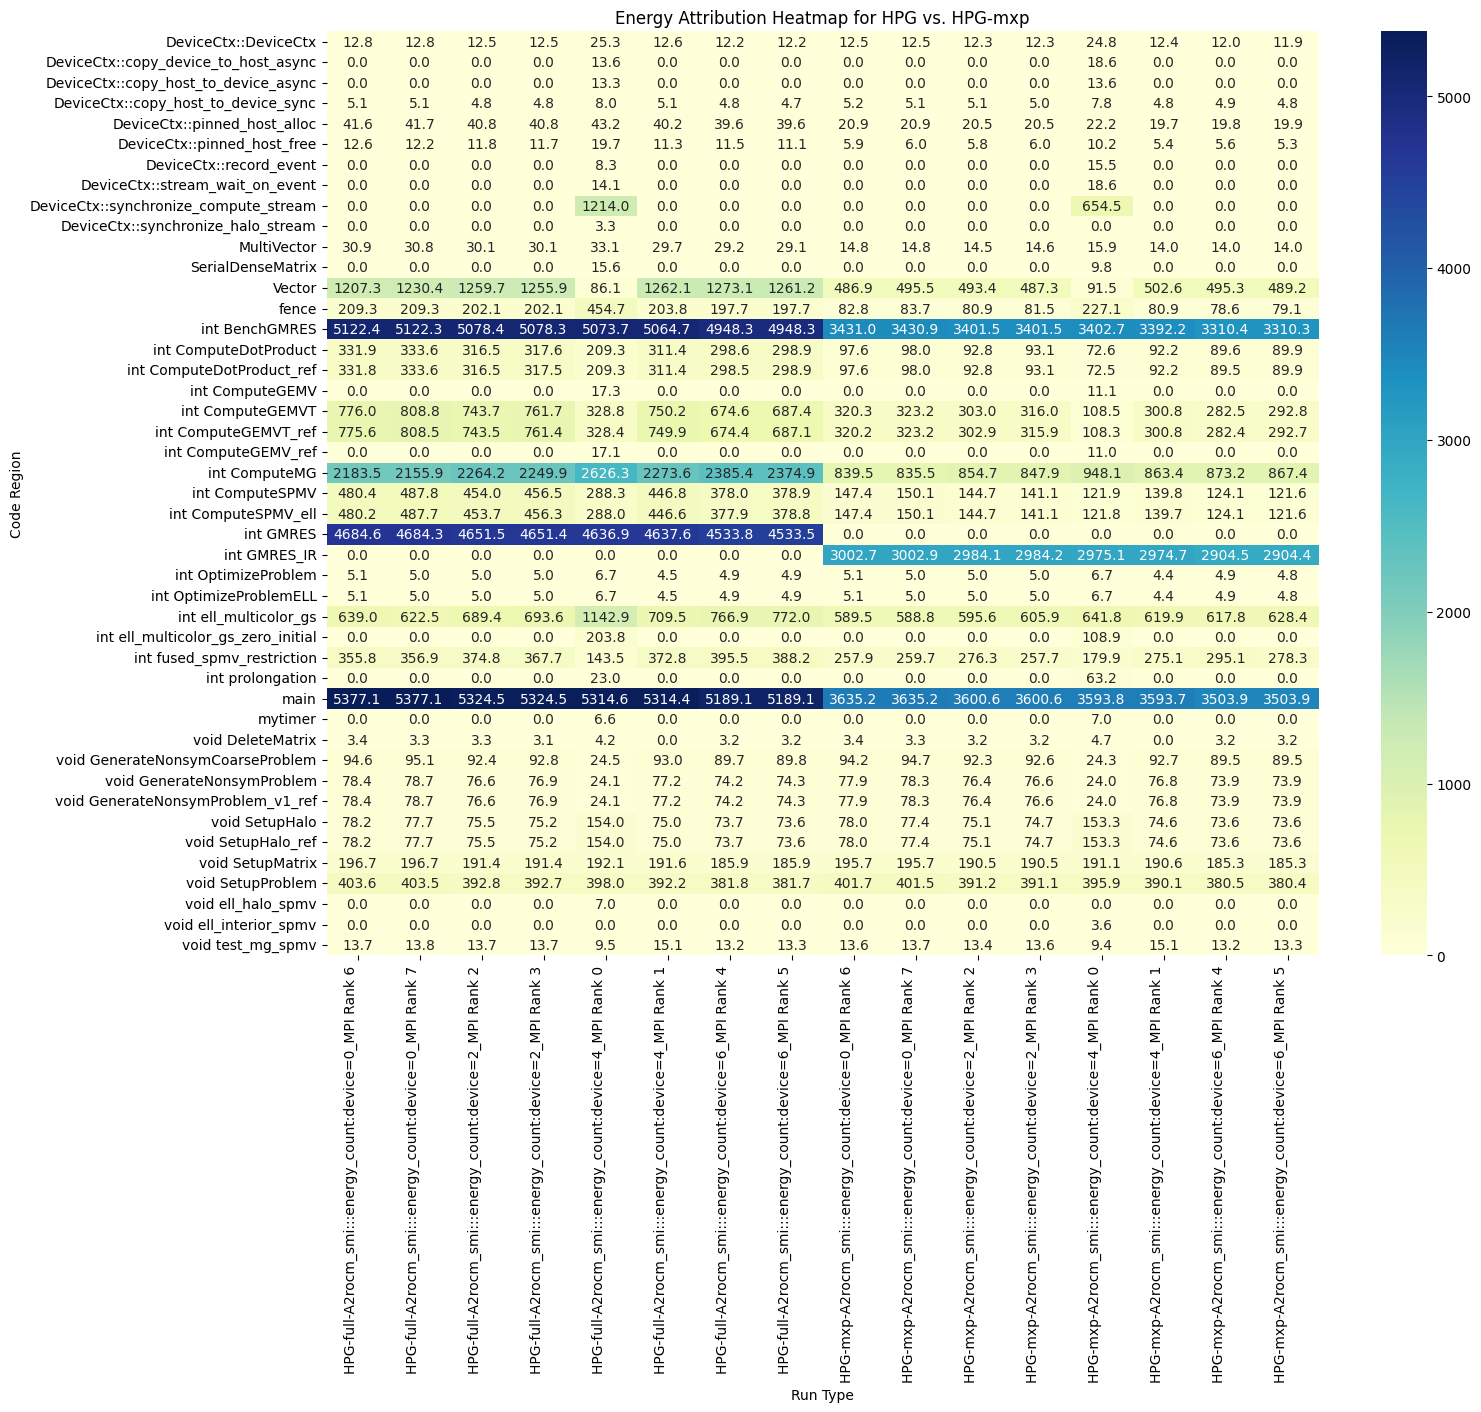

In [ ]:
# Average all the mxp runs and non-mxp runs each
hpg_avg = hpg_run_attributions.copy()
hpg_avg = hpg_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
hpg_avg['Run'] = 'HPG-full'
# Sort the dataframe by value
hpg_avg = hpg_avg.sort_values(by='Value', ascending=False)

hpg_mxp_avg = hpg_mxp_run_attributions.copy()
hpg_mxp_avg = hpg_mxp_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
hpg_mxp_avg['Run'] = 'HPG-mxp'

# First, replace all function names with the following function:
def replace_prefix_and_suffix(name: str) -> str:
    """Replace the prefix and everything after the `<` or `(` in the function name."""
    # name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
    if '<' in name:
        name = name.split('<')[0]
    if '(' in name:
        name = name.split('(')[0]
    return name.strip()

hpg_mxp_avg['Code Region'] = hpg_mxp_avg['Code Region'].apply(replace_prefix_and_suffix)
hpg_avg['Code Region'] = hpg_avg['Code Region'].apply(replace_prefix_and_suffix)
visualize_dataframe(hpg_avg)
visualize_dataframe(hpg_mxp_avg)

# hpg_mpi_funcs = hpg_avg[hpg_avg['Code Region'].str.contains('MPI')]
# hpg_mxp_mpi_funcs = hpg_mxp_avg[hpg_mxp_avg['Code Region'].str.contains('MPI')]

heatmap_data = pd.concat([hpg_avg, hpg_mxp_avg])
# Filter for values > 0
heatmap_data = heatmap_data[heatmap_data['Value'] > 3]
heatmap_data = heatmap_data.pivot_table(index='Code Region', columns=['Run', 'Metric'], values='Value', fill_value=0.0, sort=True)
visualize_dataframe(heatmap_data)
# Sort by the sum of both columns

# Show the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Energy Attribution Heatmap for HPG vs. HPG-mxp")
plt.xlabel("Run Type")
plt.xticks(rotation=90, ha='right')
plt.ylabel("Code Region")
plt.show()

Attributions already computed, returning cached results.


Run,Node,Code Region,Metric,Value
frontier02128-xhpgmp-128_128_128_--run_type=standalone_ref,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,5599.317401
frontier02128-xhpgmp-128_128_128_--run_type=standalone_ref,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,5599.316550
frontier02129-xhpgmp-128_128_128_--run_type=standalone_ref,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,5483.604024
frontier02129-xhpgmp-128_128_128_--run_type=standalone_ref,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,5483.600662
frontier02128-xhpgmp-128_128_128_--run_type=standalone_ref,node0,"int BenchGMRES<double, float, float>",A2rocm_smi:::energy_count:device=0_MPI Rank 7,5361.866095
frontier02128-xhpgmp-128_128_128_--run_type=standalone_ref,node0,"int BenchGMRES<double, float, float>",A2rocm_smi:::energy_count:device=0_MPI Rank 6,5360.866767
frontier02131-xhpgmp-128_128_128_--run_type=standalone_ref,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,5224.872194
frontier02131-xhpgmp-128_128_128_--run_type=standalone_ref,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,5224.871956
frontier02129-xhpgmp-128_128_128_--run_type=standalone_ref,node0,"int BenchGMRES<double, float, float>",A2rocm_smi:::energy_count:device=0_MPI Rank 6,5215.457710
frontier02129-xhpgmp-128_128_128_--run_type=standalone_ref,node0,"int BenchGMRES<double, float, float>",A2rocm_smi:::energy_count:device=0_MPI Rank 7,5214.156430


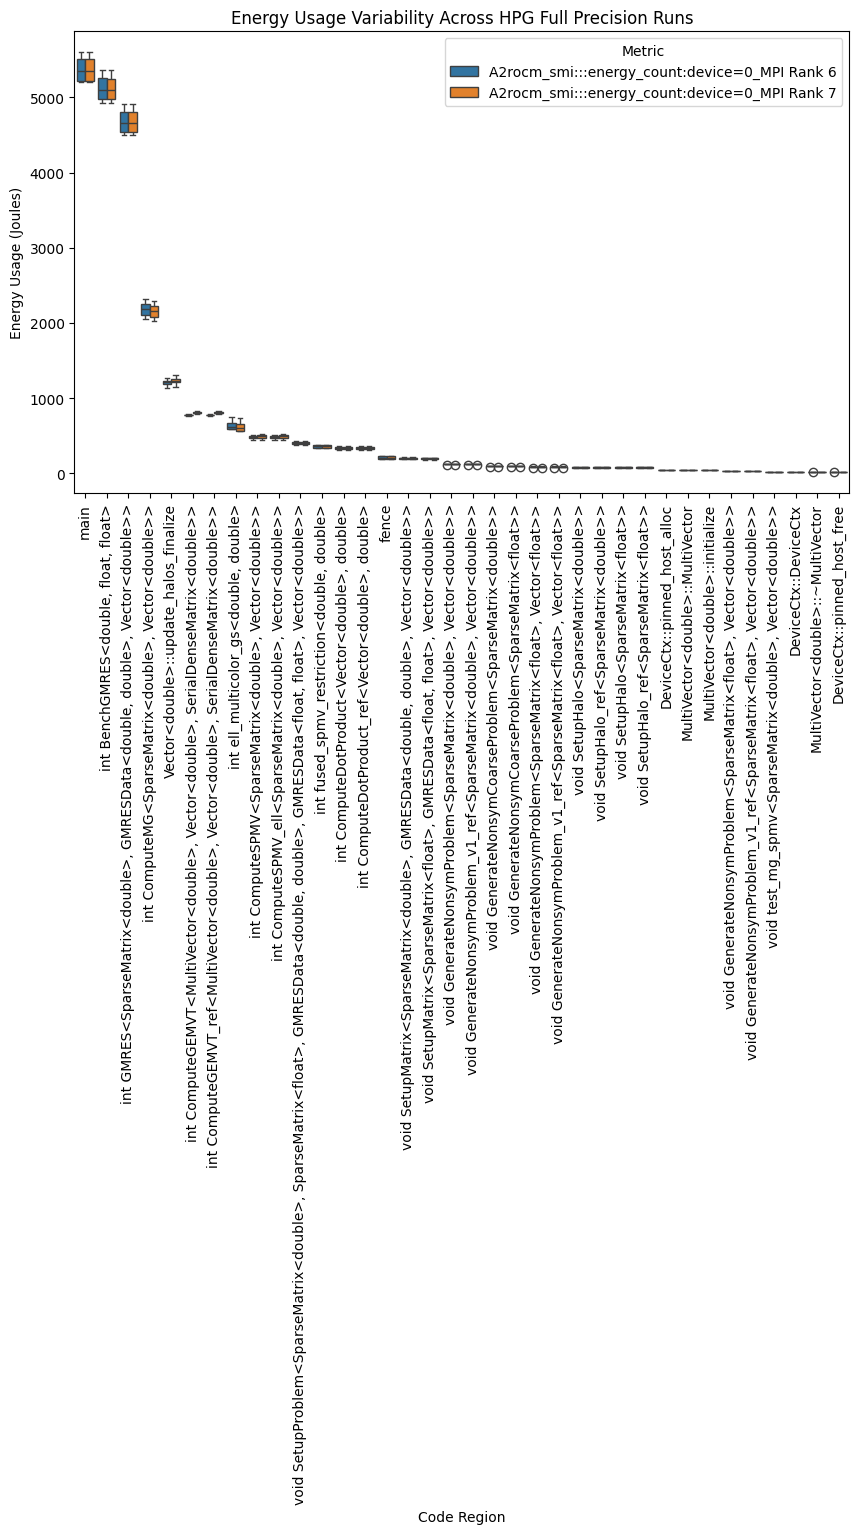

In [ ]:
run_attributions = hpg_runs.compute_attribution_across_runs(
    ranks_to_metrics = HPG_RANKS_TO_METRICS
)

def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
    return match.group(0) if match else s

plt.figure(figsize=(10, 6))
run_attributions = run_attributions[run_attributions['Metric'].str.contains('A2rocm_smi:::energy_count:device=0')]
run_attributions = run_attributions[run_attributions['Value'] > 5]  # Filter out small values
run_attributions = run_attributions[run_attributions['Node'] == 'node0']
run_attributions['Code Region'] = run_attributions['Code Region'].apply(take_alphanumeric)

# # Only look at code regions with more than 1 entry
run_attributions = run_attributions.groupby('Code Region').filter(lambda x: len(x) > 1)
# # Sort by median value
run_attributions = run_attributions.sort_values(by='Value', ascending=False)
visualize_dataframe(run_attributions)

sns.boxplot(x='Code Region', y='Value', hue='Metric', data=run_attributions)
plt.title("Energy Usage Variability Across HPG Full Precision Runs")
plt.xticks(rotation=90)
plt.ylabel('Energy Usage (Joules)')
plt.show()

Attributions already computed, returning cached results.


Run,Node,Code Region,Metric,Value
frontier02128-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,3851.773954
frontier02128-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,3851.773954
frontier02129-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,3640.051409
frontier02129-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,3640.046508
frontier02128-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,"int BenchGMRES<double, float, float>",A2rocm_smi:::energy_count:device=0_MPI Rank 6,3632.253953
frontier02128-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,"int BenchGMRES<double, float, float>",A2rocm_smi:::energy_count:device=0_MPI Rank 7,3631.028700
frontier02130-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,3526.923777
frontier02130-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,3526.917514
frontier02131-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 6,3522.100196
frontier02131-xhpgmp-128_128_128_--run_type=standalone_mxp,node0,main,A2rocm_smi:::energy_count:device=0_MPI Rank 7,3522.094665


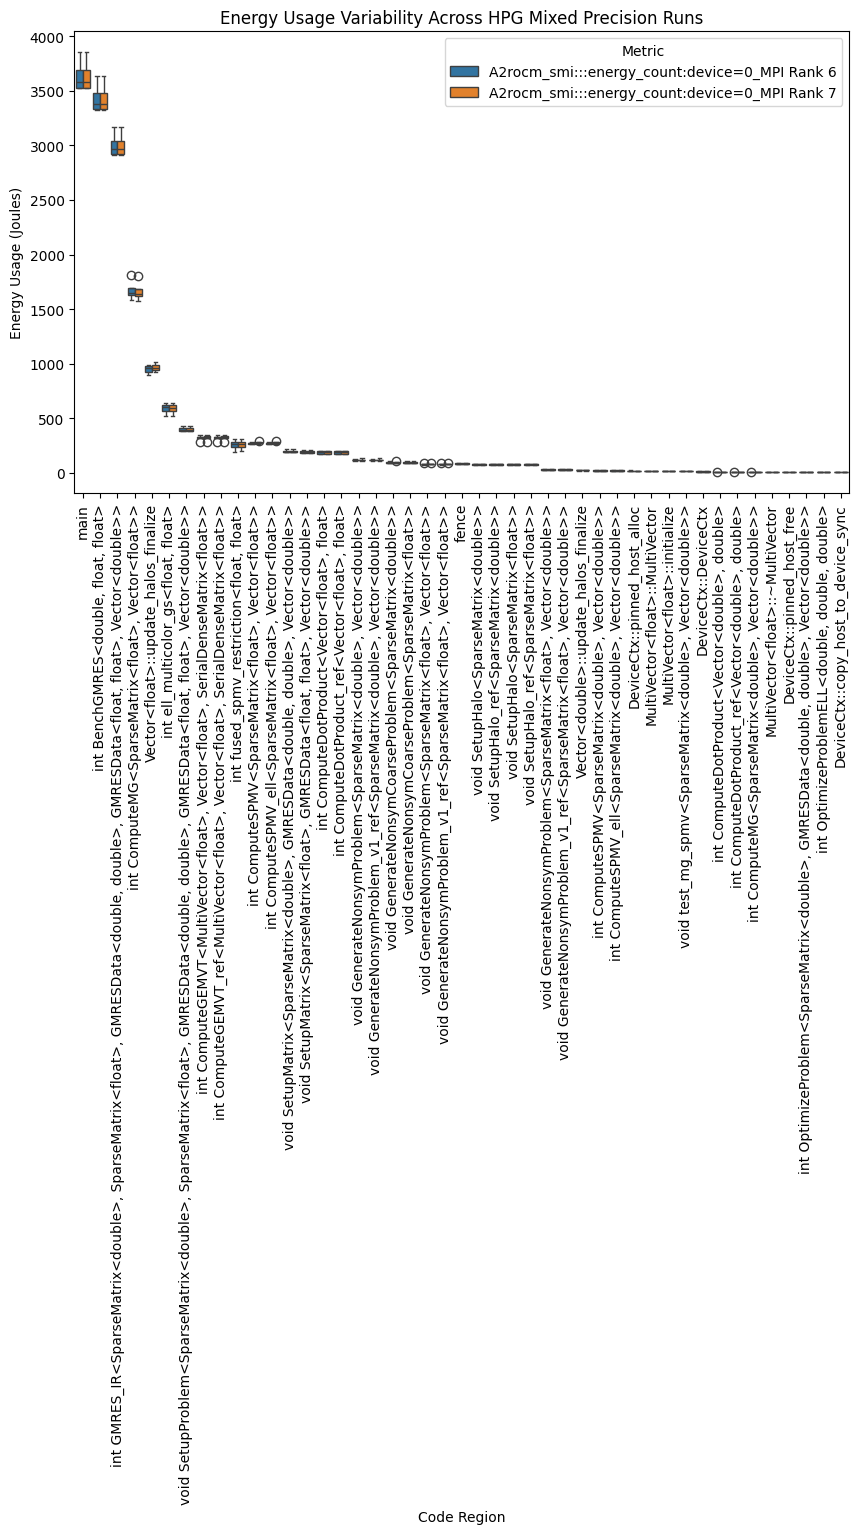

In [ ]:
run_attributions = hpg_mxp_runs.compute_attribution_across_runs(
    ranks_to_metrics = HPG_RANKS_TO_METRICS
)

def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
    return match.group(0) if match else s

plt.figure(figsize=(10, 6))
run_attributions = run_attributions[run_attributions['Metric'].str.contains('A2rocm_smi:::energy_count:device=0')]
run_attributions = run_attributions[run_attributions['Value'] > 5]  # Filter out small values
run_attributions = run_attributions[run_attributions['Node'] == 'node0']
run_attributions['Code Region'] = run_attributions['Code Region'].apply(take_alphanumeric)

# # Only look at code regions with more than 1 entry
run_attributions = run_attributions.groupby('Code Region').filter(lambda x: len(x) > 1)
# # Sort by median value
run_attributions = run_attributions.sort_values(by='Value', ascending=False)
visualize_dataframe(run_attributions)

sns.boxplot(x='Code Region', y='Value', hue='Metric', data=run_attributions)
plt.title("Energy Usage Variability Across HPG Mixed Precision Runs")
plt.xticks(rotation=90)
plt.ylabel('Energy Usage (Joules)')
plt.show()